In [14]:
!pip install mglearn

In [15]:
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import mglearn
import matplotlib.pyplot as plt

In [16]:
# Generating the dataset
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)


In [17]:
mlp = MLPClassifier(solver='lbfgs', random_state=0)
mlp.fit(X_train, y_train)

MLPClassifier(random_state=0, solver='lbfgs')

Text(0, 0.5, 'Feature 1')

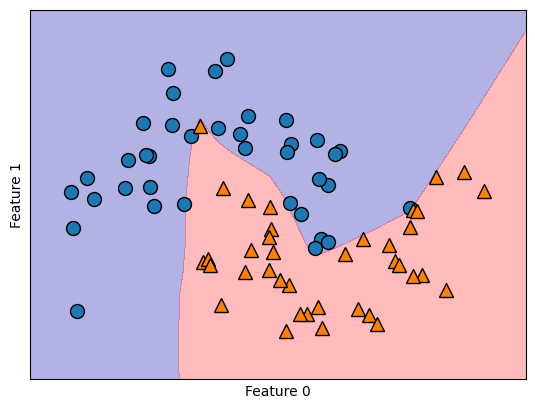

In [18]:
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

The neural network learned a very nonlinear but relatively smooth decision boundary. We used solver='lbfgs'.

By default, the MLP uses **100 hidden nodes**, which is quite a lot for this small dataset. We can reduce the number (which reduces the complexity of the model) and still get a good result

In [19]:
mlp1 = MLPClassifier(solver='lbfgs',
                     random_state=0,
                     hidden_layer_sizes=[10],
                     max_iter=1000) # 1 hidden layer with 10 neurons(hidden units)
mlp1.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=[10], max_iter=1000, random_state=0,
              solver='lbfgs')

Text(0, 0.5, 'Feature 1')

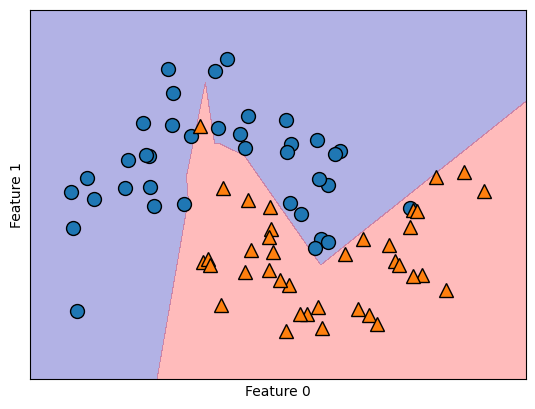

In [20]:
mglearn.plots.plot_2d_separator(mlp1, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

With only 10 hidden units(neurons), the decision boundary looks somewhat more ragged. The default nonlinearity is relu. With a single hidden layer, this means the decision function will be made up of 10 straight line segments. If we want a smoother decision boundary, we could add more hidden units add a second hidden layer or use the tanh nonlinearity.

In [21]:
# using two hidden layers, with 10 units each
mlp2 = MLPClassifier(solver='lbfgs',
                     random_state=0,
                     hidden_layer_sizes=[10,10]) # 2 hidden layers with 10 neurons each

mlp2.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=[10, 10], random_state=0, solver='lbfgs')

Text(0, 0.5, 'Feature 1')

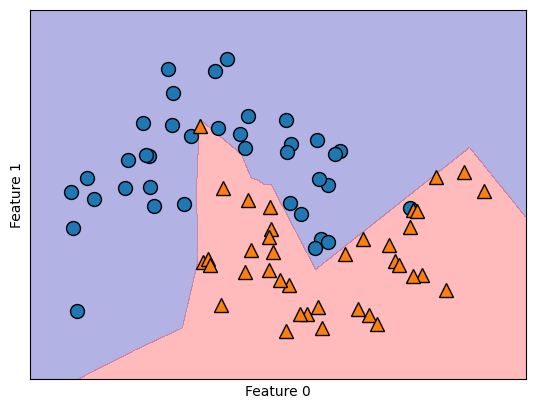

In [22]:
mglearn.plots.plot_2d_separator(mlp2, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

In [23]:
# using two hidden layers, with 10 units each, now with tanh nonlinearity
mlp3 = MLPClassifier(solver='lbfgs',
                     random_state=0,
                     activation='tanh',
                     hidden_layer_sizes=[10, 10],
                     max_iter=1000)

mlp3.fit(X_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=[10, 10], max_iter=1000,
              random_state=0, solver='lbfgs')

Text(0, 0.5, 'Feature 1')

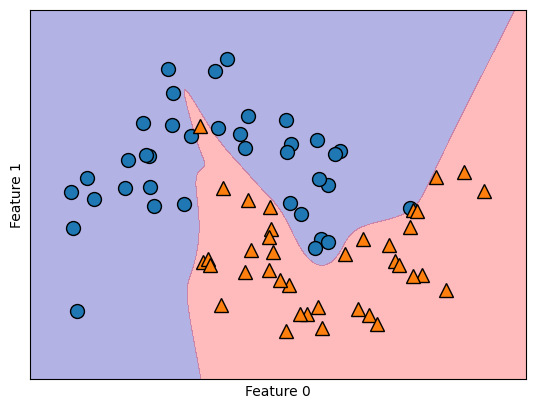

In [24]:
mglearn.plots.plot_2d_separator(mlp3, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")

Finally, we can also control the complexity of a neural network by using an **l2 penalty** to shrink the weights toward zero, as did in ridge regression and the linear classifiers.

The parameter for this in the MLPClassifier is **alpha** (as in the linear regression models), and it’s set to a very low value (little regularization) by default(alpha=0.0001).

Below plots shows the effect of different values of alpha on the two_moons dataset, using two hidden layers of 10 or 100 units each:

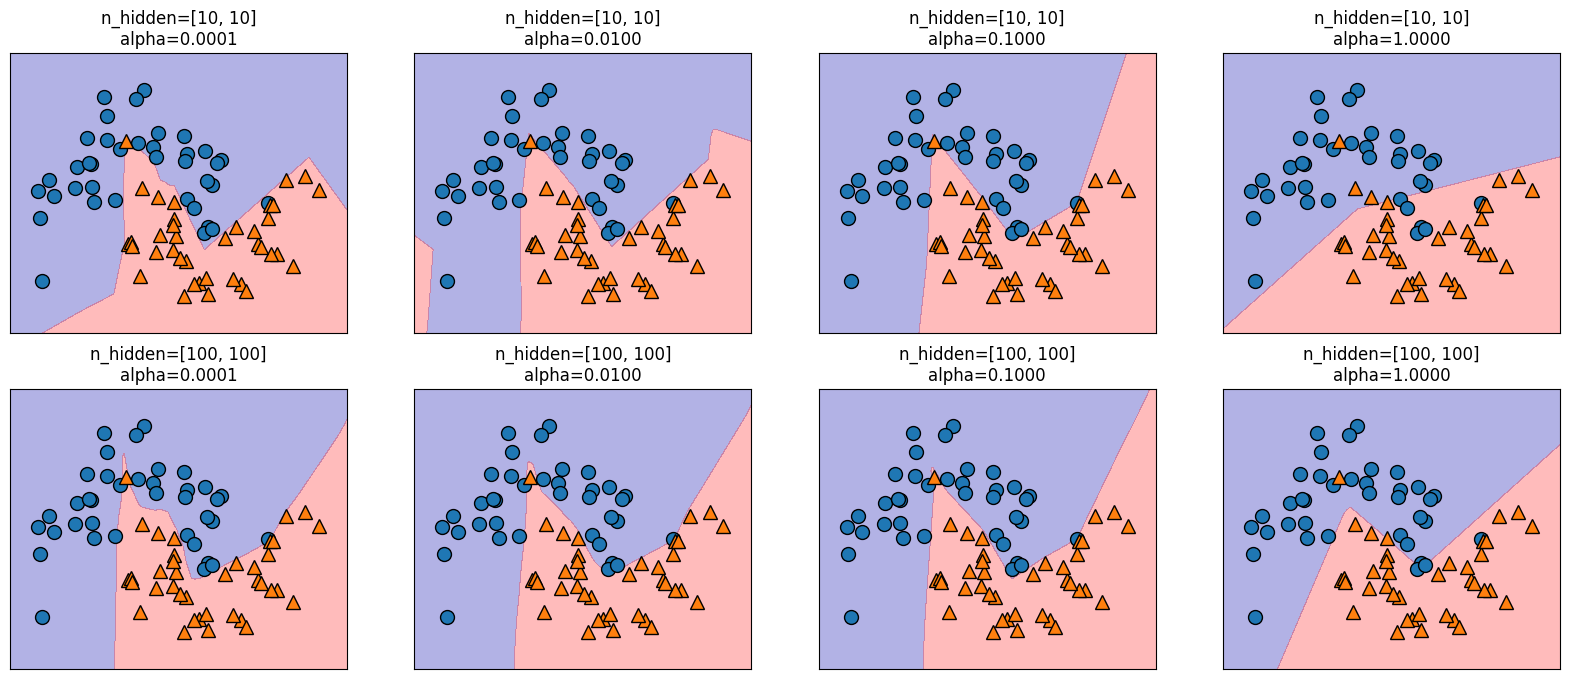

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
    for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
        mlp = MLPClassifier(solver='lbfgs', random_state=0,
                            hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes],
                            alpha=alpha,
                            max_iter=1000)
        mlp.fit(X_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)
        ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(
                      n_hidden_nodes, n_hidden_nodes, alpha))

As we have probably have realized by now, there are many ways to control the complexity of a neural network: **the number of hidden layers, the number of units in each hidden layer, and the regularization (alpha)**. There are even more.

An important property of neural networks is that their weights are set randomly before learning is started, and this random initialization affects the model that is learned. That means that even when using exactly the same parameters, we can obtain very different models when using different random seeds. If the networks are large, and their complexity is chosen properly, this should not affect accuracy too much, but it is worth keeping in mind (particularly for smaller networks).

**random_state** fixes the random seed used for weight initialization (and data shuffling in some solvers), ensuring that the MLP produces reproducible and comparable results across runs.

Below plots shows several models, all learned with the same settings of the parameters and changes the random_state values.

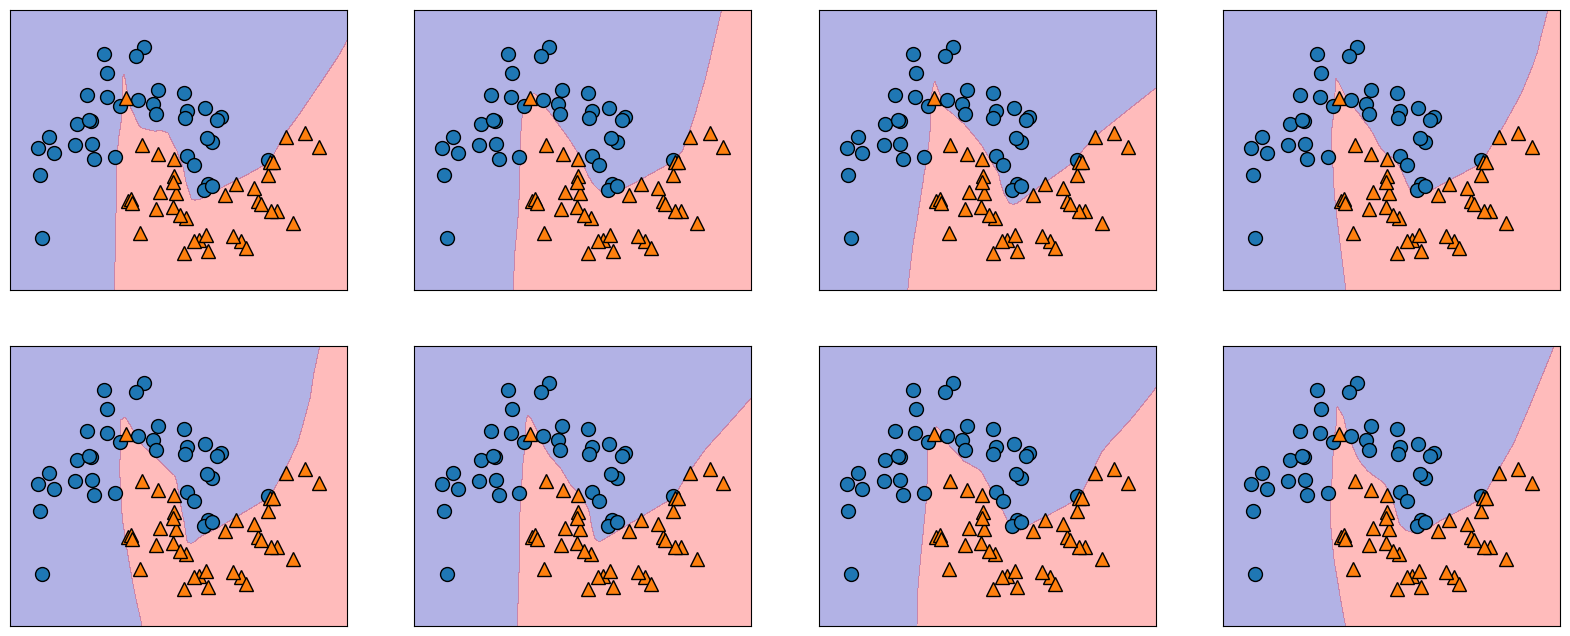

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, ax in enumerate(axes.ravel()):
    mlp = MLPClassifier(solver='lbfgs', random_state=i,
                        hidden_layer_sizes=[100, 100])
    mlp.fit(X_train, y_train)
    mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)

We can see slight changes in the decision boundry.